# GRPO Vision Sanity Check & Story Evaluation
This notebook runs a 100-sample sanity check on the **Qwen3-VL-4B-Thinking** model using GRPO. 
It features a raw inference block before fine-tuning. The reward function ranks generation alignments with the reference narrative (via cosine similarity). 
We then evaluate the outputs using an LLM-as-a-judge (`gemma-4-31b-it` via `GEMINI_FREE_API_KEY_1`) following the **AIStory Similarity Benchmark**.

In [1]:
%pip cache purge
%pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
%pip uninstall torch torchvision torchaudio -y
%pip install torch==2.10.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
%pip install transformers==4.57.0 trl==0.24.0 xformers accelerate peft bitsandbytes
%pip install pillow python-dotenv datasets sentence-transformers google-genai
%pip install ipywidgets
%pip install pillow matplotlib

Files removed: 52 (952.0 MB)
Directories removed: 0
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-7d1nyeaw/unsloth_439059dd3107440db91d7cb983345557
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-7d1nyeaw/unsloth_439059dd3107440db91d7cb983345557
  Resolved https://github.com/unslothai/unsloth.git to commit b3640802253f64117ee228718be7fab32e47aa5f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 26.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 37.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 78.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2

In [1]:
!python -m scripts.train --target_size 3500 --max_pages 20

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Downloaded data!
✅ Đã lọc còn 8367 mẫu (num_pages <= 20).
✅ Đã sample thành công 3488 mẫu (Gaussian Shape).
Prepared Dataset for training
==((====))==  Unsloth 2026.5.2: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    NVIDIA GeForce RTX 5070 Ti. Num GPUs = 1. Max memory: 15.477 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,488 | Num Epochs = 1 | Total steps = 3,488
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs =

In [2]:
import os
import re
import gc
import json
import random
import torch
torch._dynamo.config.disable = True
import torch.nn.functional as F
from PIL import Image
import copy
import matplotlib.pyplot as plt
import math
from dotenv import load_dotenv
from datasets import Dataset
from transformers import AutoProcessor, TextStreamer
from sentence_transformers import SentenceTransformer
from trl import GRPOConfig, GRPOTrainer
from unsloth import FastVisionModel, is_bfloat16_supported
from google import genai
from google.genai import types

load_dotenv('.env')

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/venv/main/lib/python3.12/site-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


True

In [3]:
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"Torch version: {torch.__version__}")


Is CUDA available: True
Torch version: 2.10.0+cu128


## 1. Data Preparation
We'll replicate the core logic from `generate_cot_and_story.py` to load 100 sequences and dynamically resolve image paths from `data/final/train`.

In [2]:
import zipfile
from huggingface_hub import snapshot_download

# 1. Cấu hình thông tin
REPO_ID = "TQZinh/Manga_Story_Gen"  # Ví dụ: "vinh/manga-dataset"
LOCAL_DIR = "./"                     # Tải về thư mục gốc hiện tại

print(f"--- Đang bắt đầu tải dataset từ {REPO_ID} ---")

# 2. Tải toàn bộ repository về
# Nếu dataset công khai, bạn có thể bỏ tham số token
path = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_DIR,
    token=os.environ.get("HF_TOKEN"), 
    local_dir_use_symlinks=False  # Ép kiểu tải file thực tế thay vì link ảo
)

print(f"✅ Đã tải xong về: {path}")

# 3. Tự động tìm và giải nén các file .zip
print("--- Đang kiểm tra và unzip các file nén ---")
for file in os.listdir(LOCAL_DIR):
    if file.endswith(".zip"):
        zip_path = os.path.join(LOCAL_DIR, file)
        print(f"📦 Đang giải nén: {file}...")
        
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                # Giải nén ngay tại thư mục hiện tại
                zip_ref.extractall(LOCAL_DIR)
            print(f"   ➤ Thành công!")
            
            # (Tùy chọn) Xóa file zip sau khi giải nén để tiết kiệm bộ nhớ
            # os.remove(zip_path)
            # print(f"   ➤ Đã xóa file zip gốc.")
        except Exception as e:
            print(f"   ❌ Lỗi khi giải nén {file}: {e}")

print("--- HOÀN TẤT ---")


--- Đang bắt đầu tải dataset từ TQZinh/Manga_Story_Gen ---


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

manga_detail.json: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md:   0%|          | 0.00/114 [00:00<?, ?B/s]

manga_dataset.zip:   0%|          | 0.00/3.59G [00:00<?, ?B/s]

✅ Đã tải xong về: /workspace/Manga_Story_Gen
--- Đang kiểm tra và unzip các file nén ---
📦 Đang giải nén: manga_dataset.zip...
   ➤ Thành công!
--- HOÀN TẤT ---


✅ Đã lọc còn 8367 mẫu (num_pages <= 15).
✅ Đã sample thành công 3488 mẫu với Shape là Phân phối chuẩn (Gaussian).


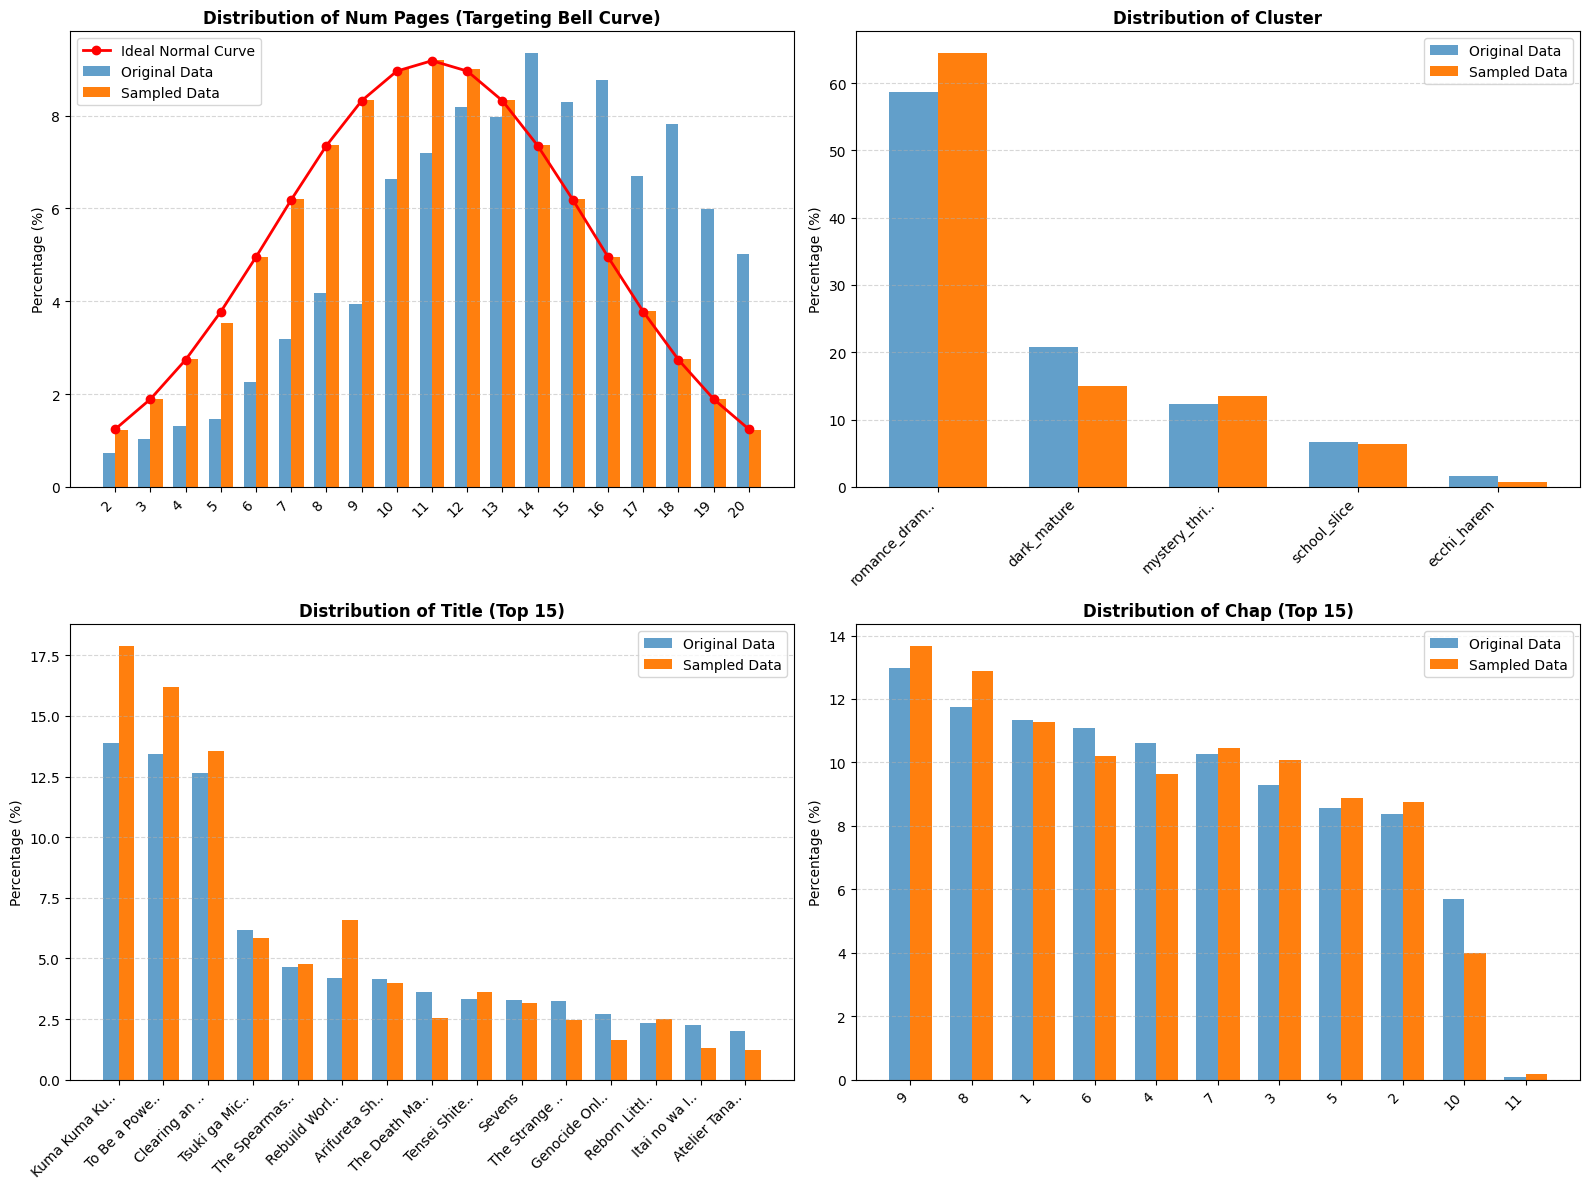

In [4]:
# Paths
BASE_DIR = os.getcwd()
MANGA_DIR = 'data/manga_dataset/image'
FINAL_TRAIN_DIR = 'data/manga_dataset/final/train'
COT_DIR = 'data/manga_dataset/synthetic_cot'
STORY_DIR = 'data/manga_dataset/generated_story'
GENRE_PATH = 'data/manga_detail.json'

# Utilities from Phase 3 Scripts
def natural_sort_key(s):
    return [int(c) if c.isdigit() else c.lower() for c in re.split(r'(\d+)', s)]

def load_genre_data():
    if not os.path.exists(GENRE_PATH):
        return {}
    with open(GENRE_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)
    result = {}
    for item in data:
        genres = item.get('genres', [])
        result[item['name']] = genres
        normalized = re.sub(r'\s*\(?:WN|LN\)\s*$', '', item['name']).strip()
        result[normalized] = genres
    return result

CLUSTER_RULES = [
    ("dark_mature",      {"Horror", "Tragedy", "Psychological", "Mature", "Adult"}),
    ("mystery_thriller", {"Mystery", "Supernatural"}),
    ("romance_drama",    {"Romance", "Drama", "Shoujo", "Josei"}),
    ("school_slice",     {"School Life", "Slice of Life"}),
    ("ecchi_harem",      {"Ecchi", "Harem"}),
    ("mecha_scifi",      {"Mecha", "Sci-fi"}),
    ("comedy_light",     {"Comedy"}),
    ("shounen_battle",   {"Shounen"}),
    ("isekai_adventure", {"Adventure", "Fantasy"}),
]

def assign_cluster(title, genre_data_map):
    genres = set(genre_data_map.get(title, []))
    for cluster_name, trigger_genres in CLUSTER_RULES:
        if genres & trigger_genres:
            return cluster_name
    return "default"

def resolve_image_paths(json_data):
    title = json_data['name']
    chap = str(json_data['chap'])
    start_file = json_data['start']
    num_pages = int(json_data['num_pages'])
    
    manga_title_dir = os.path.join(MANGA_DIR, title)
    if not os.path.isdir(manga_title_dir): return []
    
    chap_dir = os.path.join(manga_title_dir, f"Chap_{chap}")
    if not os.path.isdir(chap_dir):
        possible_dirs = []
        for d in os.listdir(manga_title_dir):
            pot_dir = os.path.join(manga_title_dir, d)
            if os.path.isdir(pot_dir) and start_file in os.listdir(pot_dir):
                possible_dirs.append((pot_dir, d))
        found = False
        if len(possible_dirs) == 1:
            chap_dir = possible_dirs[0][0]
            found = True
        elif len(possible_dirs) > 1:
            for pot_dir, d_name in possible_dirs:
                if re.search(rf'(?<!\d){chap}(?!\d)', d_name):
                    chap_dir = pot_dir
                    found = True
                    break
            if not found: chap_dir, found = possible_dirs[0][0], True
        if not found: return []
    
    all_images = sorted(
        [f for f in os.listdir(chap_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))],
        key=natural_sort_key
    )
    if start_file not in all_images: return []
    start_idx = all_images.index(start_file)
    selected = all_images[start_idx : start_idx + num_pages]
    return [os.path.join(chap_dir, f) for f in selected]

# Build the subset of data
genre_data_map = load_genre_data()
all_train_files = [f for f in os.listdir(FINAL_TRAIN_DIR) if f.endswith('.json')]
sampled_files = all_train_files

data_list = []
for fname in sampled_files:
    json_path = os.path.join(FINAL_TRAIN_DIR, fname)
    with open(json_path, 'r', encoding='utf-8') as f:
        json_data = json.load(f)
    
    cluster = assign_cluster(json_data['name'], genre_data_map)
    image_paths = resolve_image_paths(json_data)
    
    # === BẮT BUỘC: Lọc số lượng ảnh đồng bộ với Inference ===
    if not image_paths:
        continue
    
    cot_path = os.path.join(COT_DIR, cluster, fname.replace('.json', '_cot.md'))
    if not os.path.exists(cot_path): continue
        
    with open(cot_path, 'r', encoding='utf-8') as f:
        cot_content = f.read().strip()
    if not cot_content: continue

    story_path = os.path.join(STORY_DIR, cluster, fname.replace('.json', '_story.json'))
    if not os.path.exists(story_path): continue
        
    with open(story_path, 'r', encoding='utf-8') as f:
        story_content = json.load(f).get("story", "")
    if not story_content.strip(): continue

    # ====== Build GRPO Prompt ======
    # 1. Định nghĩa System Prompt (Luật chơi, Format XML)
    system_prompt = """You are a professional novel writer. Your task is to write the novel chapter inside <story>...</story> and reasoning inside <think>...</think>.
You NEVER output anything outside these tag pairs. You NEVER skip or omit <story>...</story> tags or <think>...</think> tag."""

    # 2. Định nghĩa User Prompt (Nhiệm vụ cụ thể cho sample này)
    user_instruction = """Let's think step by step. Analyze the provided manga panels step-by-step inside <think> tags.
Then write a compelling novel chapter inside <story> tags based on the visuals.
REMINDER: You MUST wrap your story in <story>...</story>."""

    # 3. Xây dựng cấu trúc prompt đa vai trò (Multi-role)
    prompt = [
        # Khối System
        {
            "role": "system",
            "content": [{"type": "text", "text": system_prompt}]
        },
        # Khối User (Chứa instruction + Toàn bộ list ảnh)
        {
            "role": "user",
            "content": [{"type": "text", "text": user_instruction}]
        }
    ]

    # Thêm các node image vào content của tin nhắn User
    for _ in image_paths:
        prompt[1]["content"].append({"type": "image"})
            
    full_answer = f"<think>\n{cot_content}\n</think>\n<story>\n{story_content.strip()}\n</story>"
    
    data_list.append({
        "prompt": prompt, # Giờ đây prompt là một list chứa 2 roles: system và user
        "image_paths": image_paths,
        "num_pages": len(image_paths),
        "answer": full_answer,
        "title": json_data['name'],   
        "chap": str(json_data['chap']), 
        "cluster": cluster
    })

import math
import random
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from datasets import Dataset
# =====================================================================
# 1. THUẬT TOÁN LỌC VÀ LẤY MẪU THEO PHÂN PHỐI CHUẨN (GAUSSIAN)
# =====================================================================
# Lọc bỏ các mẫu có num_pages > 15
max_pages = 20
filtered_data = [d for d in data_list if d['num_pages'] <= max_pages]
if not filtered_data:
    raise ValueError(f"Không có dữ liệu thỏa mãn num_pages <= {max_pages}.")
# Tìm số trang min, max để căn giữa đường cong phân phối chuẩn
min_pages = min(d['num_pages'] for d in filtered_data)

# Định nghĩa tham số cho Phân phối chuẩn
mu = (min_pages + max_pages) / 2.0   # Giá trị trung bình (Đỉnh chuông nằm ở giữa)
sigma = (max_pages - min_pages) / 4.0  # Độ lệch chuẩn (Độ rộng của chuông)
# Tính tỷ lệ (ratios) lý tưởng theo hàm mật độ xác suất (PDF) của phân phối chuẩn
normal_weights = {}
total_weight = 0
for pages in range(min_pages, max_pages + 1):
    weight = math.exp(-0.5 * ((pages - mu) / sigma) ** 2)
    normal_weights[pages] = weight
    total_weight += weight
# Chuẩn hóa để tổng tỷ lệ = 1.0 (100%)
normal_ratios = {k: v / total_weight for k, v in normal_weights.items()}
# Mục tiêu là ~3500 mẫu (Nằm trong khoảng 3000 <= x <= 4000)
TARGET_SIZE = 3500
sampled_data = []
# Bắt đầu lấy mẫu
for pages, ratio in normal_ratios.items():
    # Số lượng mục tiêu cần lấy cho số trang này để tạo dáng chuông
    quota = int(round(TARGET_SIZE * ratio))
    
    # Tìm những mẫu thực tế có số trang bằng 'pages'
    candidates = [d for d in filtered_data if d['num_pages'] == pages]
    
    # Lấy đủ quota, hoặc lấy tất cả nếu số thực tế ít hơn quota
    # random.sample ở đây tiếp tục giúp cân bằng tự nhiên cluster/title/chap
    if quota >= len(candidates):
        sampled_data.extend(candidates)
    else:
        sampled_data.extend(random.sample(candidates, quota))
# Điều chỉnh lại nếu vượt giới hạn 4000
if len(sampled_data) > 5000:
    sampled_data = random.sample(sampled_data, 5000)
random.shuffle(sampled_data)
print(f"✅ Đã lọc còn {len(filtered_data)} mẫu (num_pages <= 15).")
print(f"✅ Đã sample thành công {len(sampled_data)} mẫu với Shape là Phân phối chuẩn (Gaussian).")
dataset = Dataset.from_list(sampled_data)
# =====================================================================
# 2. VẼ BIỂU ĐỒ KIỂM CHỨNG BẰNG MATPLOTLIB
# =====================================================================
def plot_comparison(original, sampled, key, title, ax, top_n=15, is_num_pages=False):
    orig_counts = Counter([d[key] for d in original])
    samp_counts = Counter([d[key] for d in sampled])
    
    # Với num_pages, ta hiển thị dọc theo trục X là các con số theo thứ tự. 
    # Với các yếu tố khác, hiển thị top N
    if is_num_pages:
        labels = list(range(min_pages, max_pages + 1))
    else:
        labels = [k for k, v in orig_counts.most_common(top_n)]
    
    # Chuyển tần suất thành phần trăm (%)
    orig_pct = [orig_counts.get(l, 0) / len(original) * 100 for l in labels]
    samp_pct = [samp_counts.get(l, 0) / len(sampled) * 100 if len(sampled) else 0 for l in labels]
    
    x = np.arange(len(labels))
    width = 0.35
    
    ax.bar(x - width/2, orig_pct, width, label='Original Data', color='#1f77b4', alpha=0.7)
    ax.bar(x + width/2, samp_pct, width, label='Sampled Data', color='#ff7f0e')
    
    # Vẽ ĐƯỜNG CONG LÝ TƯỞNG MÀU ĐỎ nếu là đồ thị num_pages
    if is_num_pages:
        ideal_pct = [normal_ratios.get(l, 0) * 100 for l in labels]
        ax.plot(x, ideal_pct, color='red', marker='o', linestyle='-', linewidth=2, label='Ideal Normal Curve')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    
    # Rút gọn tên trục X nếu quá dài
    formatted_labels = [str(l)[:12] + '..' if len(str(l))>12 else str(l) for l in labels]
    ax.set_xticklabels(formatted_labels, rotation=45, ha='right')
    
    ax.set_ylabel('Percentage (%)')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
# Vẽ 4 biểu đồ
plot_comparison(filtered_data, sampled_data, 'num_pages', 'Distribution of Num Pages (Targeting Bell Curve)', axs[0, 0], is_num_pages=True)
plot_comparison(filtered_data, sampled_data, 'cluster', 'Distribution of Cluster', axs[0, 1])
plot_comparison(filtered_data, sampled_data, 'title', 'Distribution of Title (Top 15)', axs[1, 0])
plot_comparison(filtered_data, sampled_data, 'chap', 'Distribution of Chap (Top 15)', axs[1, 1])
plt.tight_layout()
plt.show()


In [5]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import math

def transform_fn(examples):
    images = []
    MAX_PIXELS = 240 * 340 # Giới hạn tổng số pixel (tương đương ảnh 512x512)
    
    for paths in examples["image_paths"]:
        batch_images = []
        for p in paths:
            img = Image.open(p).convert("RGB")
            w, h = img.size
            
            # Tính toán tỷ lệ nếu vượt quá giới hạn
            if w * h > MAX_PIXELS:
                scale = math.sqrt(MAX_PIXELS / (w * h))
                new_w, new_h = int(w * scale), int(h * scale)
                img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
            
            batch_images.append(img)
        images.append(batch_images)
        
    examples["images"] = images
    return examples


# Dùng set_transform để load ảnh on-the-fly, tránh MemoryError
dataset.set_transform(transform_fn)

print(f"✅ Successfully configured dynamic image loading.")


✅ Successfully configured dynamic image loading.


## 2. Load Model & Prepare Reward Function
We will define our Cosine Similarity Reward Function using `sentence-transformers`. It evaluates the alignment of the generated `<story>` with the reference ground-truth text.

In [ ]:
def extract_solution(generation: str):
    # Dùng regex để lấy nội dung giữa <story> và </story>
    matches = re.findall(r'<story>(.*?)</story>', generation, flags=re.DOTALL | re.IGNORECASE)
    if matches:
        # Lấy khai story cuối cùng có nội dung đáng kể
        for m in reversed(matches):
            if len(m.strip()) > 10:
                return m.strip()
        return matches[-1].strip()
    return "" 
def format_reward_func(completions, **kwargs):
    """Thưởng cho việc tuân thủ định dạng <think> và <story>"""
    rewards = []
    for completion in completions:
        text = completion[0]['content'] if isinstance(completion, list) else str(completion)
        reward = 0.0
        # Thưởng nếu có đủ cặp thẻ
        if "<think>" in text and "</think>" in text:
            reward += 0.2
        if "<story>" in text and "</story>" in text:
            reward += 0.3
        # Thưởng nếu thẻ <story> nằm sau thẻ </think>
        if "</think>" in text and "<story>" in text:
            if text.find("</think>") < text.find("<story>"):
                reward += 0.2
        rewards.append(reward)
    return rewards
    
embed_model = SentenceTransformer('all-mpnet-base-v2', device='cuda')
embed_model.eval()
def cosine_similarity_reward(prompts, completions, answer, **kwargs):
    all_completion_texts = []
    for completion_node in completions:
        # Unpack text từ format Chat
        if isinstance(completion_node, list) and len(completion_node) > 0 and 'content' in completion_node[0]:
            all_completion_texts.append(completion_node[0]['content'])
        else:
            all_completion_texts.append(str(completion_node))
            
    # 1. Trích xuất story và kiểm tra lỗi định dạng cho cả batch
    gen_solutions = []
    penalties = []
    for text in all_completion_texts:
        sol = extract_solution(text)
        gen_solutions.append(sol)
        
        # Hình phạt nếu thiếu các thẻ quan trọng
        penalty = 0.0
        if "<think>" not in text or "</think>" not in text:
            penalty += 0.25
        if "<story>" not in text or "</story>" not in text:
            penalty += 0.25
        penalties.append(penalty)
        
    # 2. Batch Encoding (Nhanh hơn rất nhiều so với chạy vòng lặp)
    with torch.no_grad():
        # encode hỗ trợ truyền vào một list string
        embeddings_gen = embed_model.encode(gen_solutions, convert_to_tensor=True, device='cuda')
        ref_solutions = [extract_solution(ans) if '<story>' in ans else ans for ans in answer]
        embeddings_ref = embed_model.encode(ref_solutions, convert_to_tensor=True, device='cuda')
        
        # Tính similarity cho cả batch một lúc
        sim_scores = F.cosine_similarity(embeddings_gen, embeddings_ref)
        
    # 3. Tổng hợp reward và trừ penalty
    # sim_scores ở dạng tensor, ta trừ đi tensor penalties
    rewards = (sim_scores - torch.tensor(penalties, device=sim_scores.device)).tolist()
    
    return rewards

In [7]:
# Load Model Configuration
max_seq_length = 32768

model, tokenizer = FastVisionModel.from_pretrained(
    model_name = "unsloth/Qwen3-VL-4B-Thinking-unsloth-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    fast_inference = False,  # Using vllm fast inference to speed up raw interference later
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False, 
    finetune_language_layers   = True,  
    finetune_attention_modules = True,  
    finetune_mlp_modules       = True,  
    r = 16,           
    lora_alpha = 16,  
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_gradient_checkpointing="unsloth"

)

==((====))==  Unsloth 2026.5.2: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    NVIDIA GeForce RTX 5070 Ti. Num GPUs = 1. Max memory: 15.477 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


## 4. Training Execution (GRPOTrainer)

In [ ]:
# Switch model back to training mode
FastVisionModel.for_training(model)

training_args = GRPOConfig(
    output_dir="outputs_grpo",
    learning_rate=5e-6,
    lr_scheduler_type="cosine",
    logging_steps=1,
    adam_beta1 = 0.9,
    adam_beta2 = 0.99,
    weight_decay = 0.1,
    warmup_ratio=0.1,
    num_train_epochs=1,
    max_steps=-1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    bf16=is_bfloat16_supported(),
    fp16=not is_bfloat16_supported(),
    optim="paged_adamw_8bit",
    report_to="none",
    remove_unused_columns=False,
    # === GRPO Specific Fixes ===
    num_generations=6,
    generation_batch_size=6,
    max_grad_norm = 0.1,
    max_completion_length=1536,     # Độ dài tối đa của câu trả lời
    max_prompt_length=32768,
    importance_sampling_level = "sequence",
    mask_truncated_completions = False,
    loss_type = "dr_grpo",
    push_to_hub = True,
    hub_model_id = "TQZinh/Manga_Story_Gen_GRPO",
    hub_strategy = "every_save",
    hub_private_repo = False,
    save_strategy="steps",
    save_steps=300, 
    save_total_limit=2
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[
        format_reward_func,
        cosine_similarity_reward   # Hàm reward bạn đã định nghĩa
        # Bạn có thể thêm các hàm reward định dạng ở đây nếu cần
    ],
    args=training_args,
    train_dataset=dataset,
)

In [9]:
import gc
torch.cuda.empty_cache()
gc.collect()
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,488 | Num Epochs = 1 | Total steps = 5,232
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 33,030,144 of 4,470,845,952 (0.74% trained)
`generation_config` default values have been modified to match model-specific defaults: {'top_p': 0.95}. If this is not desired, please set these values explicitly.


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,-0.456000
2,-0.000000
3,0.456400


KeyboardInterrupt: 

## 5. Evaluation via AIStory Similarity Benchmark
After training or generating local inferences, we evaluate the generated vs reference stories using the `gemma-4-31b-it` LLM-as-a-judge approach via the `google-genai` SDK and exactly following the provided rubric.

## **Release previous model**

In [ ]:
import torch
import gc

# 1. Delete the model and tokenizer objects
try:
    del model
except NameError:
    pass

try:
    del tokenizer
except NameError:
    pass

# 2. Delete any other heavy objects (like Trainer or Optimizer if you just finished training)
try:
    del trainer
except NameError:
    pass

# 3. Force Python's Garbage Collector to run
gc.collect()

# 4. Clear the PyTorch CUDA cache to release memory back to the GPU
torch.cuda.empty_cache()

# 5. (Optional) Check current VRAM usage to verify it's cleared
import os
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


In [ ]:
def evaluate_story_similarity(reference_story: str, test_story: str):
    """
    Sử dụng Method 3 (Full-Text) AIStory Similarity framework tích hợp Luật chơi Re:Verse.
    Bao gồm Hệ thống phạt tỷ lệ (Proportional Penalty) và Ngưỡng điểm tối thiểu.
    """
    import time
    import json
    import re
    
    PENALTY_MAP = {
        "None": 1.0,
        "Minor": 0.9,
        "Moderate": 0.8,
        "Major": 0.7,
        "Critical": 0.6
    }
    FLOORS = {
        "character": 3,
        "plot": 2,
        "setting": 4,
        "theme": 1
    }

    prompt = f"""### PERSONA
You are a world famous narratologist and successful manga scriptwriter. Your task is to perform a high-fidelity semantic comparison between two narrative stories.

### REFERENCE STORY
{reference_story}

### TEST STORY
{test_story}

### ELEMENT_FEATURES
1. Character: Character Development.
2. Plot: Plot Structure.
3. Setting: Setting and atmosphere.
4. Theme: Thematic Coherence.

### DEFICIENCY DEFINITIONS
- None: High coherence, no hallucinations, follows narrative understanding perfectly.
- Minor: Superficial issues that don’t fundamentally compromise narrative understanding.
- Moderate: Noticeable problems that impact but don’t destroy narrative coherence.
- Major: Significant structural issues that severely compromise story quality.
- Critical: Fundamental failures that nearly eliminate narrative value.

### INSTRUCTIONS
1. Provide raw similarity scores for each feature with explanation.
2. Identify any "Deficiencies" in each feature in the TEST STORY relative to the REFERENCE.
3. Assign a "deficiency_level" based on the definitions above.
4. Output the final assessment in a valid JSON block.

### EXAMPLE
```json
{{
    "character": 90,
    "plot": 80,
    "setting": 85,
    "theme": 85,

    "character_score_explanation": "Indiana Jones and the Last Crusade features charismatic and determined protagonists similar to Raiders of the Lost Ark. Indiana Jones remains the central character, exhibiting traits such as resourcefulness, bravery, and a deep respect for history. The supporting characters, including his father, add depth and emotional complexity to the narrative, mirroring the relational dynamics seen in the reference film.",

    "plot_score_explanation": "Both films follow an adventurous quest to recover a significant historical artifact, involving a series of challenges and confrontations. The Last Crusade's plot involves the search for the Holy Grail, similar to the Ark of the Covenant quest in Raiders, combining elements of mystery, action, and suspense. While the specifics differ, the overarching structure and adventurous tone are highly similar.",

    "setting_score_explanation": "The Last Crusade, like Raiders of the Lost Ark, spans multiple exotic locations including deserts, catacombs, and ancient temples, enhancing the adventurous and historical ambiance. The settings play a crucial role in both films, providing a backdrop that is rich in history and cultural significance.",

    "theme_score_explanation": "Both films explore themes of historical preservation, the ethical responsibilities of archaeologists, and the power and danger of ancient artifacts. The Last Crusade delves into themes of faith, the father-son relationship, and the quest for eternal life, which aligns closely with the thematic elements in Raiders of the Lost Ark, such as the conflict between personal ambition and greater good.",

    "deficiency_level": "Minor"
}}
```

### TEMPLATE
```json
{{
    "character": integer range(0,100),
    "plot": integer range(0,100),
    "setting": integer range(0,100),
    "theme": integer range(0,100),

    "character_score_explanation": string,

    "plot_score_explanation": string,

    "setting_score_explanation": string,

    "theme_score_explanation": string, 

    "deficiency_level": "None|Minor|Moderate|Major|Critical"
}}
```
"""
    
    from google import genai
    from google.genai import types
    import os
    
    # client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))
    model_eval = "gemini-flash-lite-latest"
    
    generate_content_config = types.GenerateContentConfig(
        temperature=0.1,
        top_p=0.5,
        thinking_config=types.ThinkingConfig(
            thinking_level="HIGH",
        )
    )

    max_retries = 3
    # Tạo danh sách tên biến môi trường: GEMINI_API_KEY_1 đến GEMINI_API_KEY_5
    api_key_env_vars = [f"GEMINI_API_KEY_{x}" for x in range(1, 6)]
    for key_var in api_key_env_vars:
        api_key = os.environ.get(key_var)
        if not api_key:
            continue  # Nếu biến môi trường này trống, bỏ qua sang key tiếp theo
            
        client = genai.Client(api_key=api_key)
        
        for attempt in range(max_retries + 1):
            try:
                print(f"\nEvaluating via {model_eval} [Dùng {key_var}] (Attempt {attempt+1})...")
                response = client.models.generate_content(
                    model=model_eval,
                    contents=prompt,
                    config=generate_content_config,
                )
                
                raw_text = response.text
                # Trích xuất JSON từ markdown block
                json_match = re.search(r'```json\s*(.*?)\s*```', raw_text, re.DOTALL)
                if json_match:
                    data = json.loads(json_match.group(1))
                else:
                    # Fallback nếu không có block markdown
                    data = json.loads(re.search(r'\{.*\}', raw_text, re.DOTALL).group(0))
                # --- HẬU XỬ LÝ THEO LUẬT RE:VERSE ---
                deficiency = data.get("deficiency_level", "None")
                multiplier = PENALTY_MAP.get(deficiency, 1.0)
                
                # Áp dụng Penalty và Floor
                processed_data = {}
                for key in ["character", "plot", "setting", "theme"]:
                    raw_score = data.get(f"{key}", 0)
                    # 1. Phạt tỷ lệ
                    penalized = raw_score * multiplier
                    # 2. Ngưỡng tối thiểu (Floor)
                    final_score = max(penalized, FLOORS.get(key, 0))
                    processed_data[f"{key}"] = round(final_score, 2)
                    processed_data[f"{key}_score_explanation"] = data.get(f"{key}_score_explanation", "")
                # Tính lại Overall Score trung bình cộng
                overall_raw = sum(processed_data[f"{k}"] for k in ["character", "plot", "setting", "theme"]) / 4
                processed_data["overall"] = round(overall_raw, 2)
                processed_data["deficiency_level"] = deficiency
                return json.dumps(processed_data, ensure_ascii=False, indent=2)
                
            except Exception as e:
                err = str(e).lower()
                
                # NẾU BỊ LỖI QUOTA HOẶC RATE LIMIT -> BREAK vòng lặp retry để đổi Key luôn
                if any(kw in err for kw in ["429", "quota", "exhausted"]):
                    print(f"[Cảnh báo] {key_var} đã hết Quota/Bị chặn. Đang đổi sang API Key tiếp theo...")
                    break  # Nhảy thẳng sang bước lặp 'for key_var in api_key_env_vars' kế tiếp
                
                # NẾU LỖI MẠNG BÌNH THƯỜNG -> Thử lại bằng chính Key đó
                if attempt < max_retries:
                    wait_time = (attempt + 1) * 5
                    print(f"[{key_var} - Error] {e}. Thử lại sau {wait_time}s...")
                    time.sleep(wait_time)
                else:
                    print(f"[{key_var} - Critical] Lỗi đánh giá sau nhiều lần thử: {e}")
                    # Hết 3 lần thử mà vẫn lỗi mạng thì sẽ cho phép lặp sang Key tiếp theo (vòng lặp ngoài)
    # Nếu tất cả các Key từ 1->5 đều tạch / hết hạn
    print("\n[Thất bại] Đã dùng hết toàn bộ API Key từ GEMINI_API_KEY_1 đến 5 nhưng vẫn lỗi.")
    return json.dumps({"error": "All API keys exhausted or failed"})

In [ ]:
from transformers.trainer_utils import get_last_checkpoint
import os

# Đường dẫn đến thư mục output
output_dir = os.path.join(BASE_DIR, "outputs_grpo")

# Tự động tìm checkpoint cuối cùng
model_path = get_last_checkpoint(output_dir)

if model_path is None:
    print("❌ Không tìm thấy checkpoint nào trong thư mục!")
else:
    print(f"✅ Đang tải model từ checkpoint mới nhất: {model_path}")
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = model_path,
        max_seq_length = 32768,
        load_in_4bit = True,
        fast_inference = False,
    )


In [ ]:
FINAL_TEST_DIR = 'manga_dataset/final/test'
all_test_files = [f for f in os.listdir(FINAL_TEST_DIR) if f.endswith('.json')]

test_data_list = []
for fname in all_test_files:
    json_path = os.path.join(FINAL_TEST_DIR, fname)
    with open(json_path, 'r', encoding='utf-8') as f:
        json_data = json.load(f)
    
    # Sử dụng chung hàm resolve_image_paths đã khai báo ở đầu Notebook
    image_paths = resolve_image_paths(json_data)
    if not image_paths:
        continue
        
    system_prompt = """You are a professional novel writer. Your task is to write the novel chapter inside <story>...</story>.
You NEVER output anything outside this tag pair. You NEVER skip or omit <story>...</story> tags."""

    user_instruction = """Let's think step by step. Analyze the provided manga panels and then write a compelling novel chapter inside <story> tags based on the visuals.
REMINDER: You MUST wrap your story in <story>...</story>."""

    prompt = [
        {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
        {"role": "user", "content": [{"type": "text", "text": user_instruction}]}
    ]

    for _ in image_paths:
        prompt[1]["content"].append({"type": "image"})
            
    # Load Reference Story tương tự cách load Train data
    cluster = assign_cluster(json_data['name'], genre_data_map)
    story_path = os.path.join(STORY_DIR, cluster, fname.replace('.json', '_story.json'))
    ref_story = ""
    if os.path.exists(story_path):
        with open(story_path, 'r', encoding='utf-8') as f:
            ref_story = json.load(f).get("story", "")
            
    test_data_list.append({
        "prompt": prompt,
        "image_paths": image_paths,
        "answer": ref_story
    })

valid_samples = []
for data_item in test_data_list:
    content_list = data_item['prompt'][1]['content']
    img_count = sum(1 for node in content_list if isinstance(node, dict) and node.get('type') == 'image')
    if 0 < img_count <= 30 and data_item['answer']:
        valid_samples.append(data_item)

gc.collect()
torch.cuda.empty_cache()
FastVisionModel.for_inference(model)

# Đồng bộ với giới hạn lúc training
MAX_PIXELS_LIMIT = 240 * 340
eval_results = []

if len(valid_samples) > 0:
    for i, selected_data in enumerate(valid_samples):
        print(f"\n=========================================")
        print(f"SAMPLE {i+1}/{len(valid_samples)}")
        print(f"=========================================")
        
        test_sample = copy.deepcopy(selected_data['prompt'])
        ref_story = selected_data['answer']
        
        # Load và nén ảnh trực tiếp (Resampling LANCZOS)
        raw_images = selected_data['image_paths']
        loaded_images = []
        for p in raw_images:
            img = Image.open(p).convert("RGB")
            w, h = img.size
            if w * h > MAX_PIXELS_LIMIT:
                scale = math.sqrt(MAX_PIXELS_LIMIT / (w * h))
                img = img.resize((int(w * scale), int(h * scale)), Image.Resampling.LANCZOS)
            loaded_images.append(img)
                
        text_prompt = tokenizer.apply_chat_template(test_sample, tokenize=False, add_generation_prompt=True)
        
        print(f"-> Đang xử lý {len(loaded_images)} ảnh...")
        inputs = tokenizer(text=[text_prompt], images=loaded_images, return_tensors="pt").to("cuda")

        print("-> Đang sinh story (streaming)...")
        streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
        
        with torch.inference_mode():
            outputs = model.generate(
                **inputs, max_new_tokens=2048, use_cache=True, temperature=0.65, 
                top_p=0.95, repetition_penalty=1.15, pad_token_id=tokenizer.eos_token_id, streamer=streamer
            )
            
        # Giải mã và lấy phần model sinh ra
        generated_text = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

        # Trả lại VRAM lập tức
        del inputs, outputs
        torch.cuda.empty_cache()
        gc.collect()

        # Trích xuất phần text nằm trong <story>...</story>
        test_gen = extract_solution(generated_text)
        
        # Gọi Gemini đánh giá
        print(f"-> Chấm điểm bằng AI...")
        eval_output = evaluate_story_similarity(ref_story, test_gen)
        eval_results.append(str(eval_output))
        
else:
    print("Không tìm thấy dữ liệu nào hợp lệ trong tập Test (số lượng ảnh <= 10 và có answer).")


In [ ]:
if eval_results:
    import re
    char_scores = []
    plot_scores = []
    setting_scores = []
    themes_scores = []
    overall_scores = []

    # Quét regex qua toàn bộ list kết quả đã hứng
    for text in eval_results:
        # Cập nhật Regex để khớp với key mới (viết thường, không có _Score)
        # Hỗ trợ cả định dạng số thực (do penalty)
        char_match = re.search(r'"character"\s*:\s*([\d.]+)', text)
        plot_match = re.search(r'"plot"\s*:\s*([\d.]+)', text)
        setting_match = re.search(r'"setting"\s*:\s*([\d.]+)', text)
        theme_match = re.search(r'"theme"\s*:\s*([\d.]+)', text)
        overall_match = re.search(r'"overall"\s*:\s*([\d.]+)', text)
        
        if char_match: char_scores.append(float(char_match.group(1)))
        if plot_match: plot_scores.append(float(plot_match.group(1)))
        if setting_match: setting_scores.append(float(setting_match.group(1)))
        if theme_match: themes_scores.append(float(theme_match.group(1)))
        if overall_match: overall_scores.append(float(overall_match.group(1)))

    # Hàm tính Mean
    def calc_mean(scores_list):
        return sum(scores_list) / len(scores_list) if scores_list else 0.0

    print("\n" + "="*60)
    print(f"AVERAGE SCORES ACROSS {len(eval_results)} SAMPLES (Re:Verse Rules Applied)")
    print("="*60)
    print(f"Characters Mean: {calc_mean(char_scores):.2f}")
    print(f"Plot Mean:       {calc_mean(plot_scores):.2f}")
    print(f"Setting Mean:    {calc_mean(setting_scores):.2f}")
    print(f"Themes Mean:     {calc_mean(themes_scores):.2f}")
    print(f"Overall Mean:    {calc_mean(overall_scores):.2f}")
    print("="*60)
